In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)

historical_pitches = pd.read_parquet('../../data/historical_pitches.parquet')


In [3]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent
if (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))

from model_shared.db import get_read_cursor

outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'sac_fly', 'sac_bunt', 'fielders_choice', 'double_play',
    'fielders_choice_out',
    'sac_fly_double_play', 'triple_play', 'popup', 'strikeout', 'strikeout_double_play'
]

strikeout_code = ['strikeout', 'strikeout_double_play']

whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
            'double_play', 'fielders_choice_out', 'sac_fly']

bip_code = ['hit_into_play']

hit_code = ['single', 'double', 'triple', 'home_run']

walk_code = ['walk', 'intent_walk', 'hit_by_pitch']

strike_code = ['swinging_strike', 'swinging_strike_blocked', 'called_strike',  'missed_bunt']

foul_code = ['foul', 'foul_bunt', 'foul_tip', 'bunt_foul_tip']

ball_code = ['ball', 'blocked_ball']

# building targets
def categorize_pitch(row):
    event = row['events']
    bb_type = row['bb_type']
    description = row['description']

    if event in strikeout_code:
        return 'strikeout'
    elif event in out_code:
        if bb_type == 'ground_ball':
            return 'groundout'
        elif bb_type in ['fly_ball', 'line_drive', 'popup']:
            return 'flyout'
    elif event in hit_code:
        return 'hit'
    elif event in walk_code:
        return 'walk'
    
    if description in strike_code:
        return 'strike'
    elif description in foul_code:
        return 'foul'
    elif description in ball_code:
        return 'ball'
    
    return 'other' 

def get_historical_data(year=2024):
    query = """
        SELECT
            bb.player_id,
            bb.position,
            bb.ground_ball_percentage,
            bb.air_ball_percentage,
            pd.whiff_percentage,
            pd.chase_percentage,
            pd.zone_percentage,
            pd.zone_swing_percentage,
            pd.zone_contact_percentage,
            qoc.weak_percentage,
            qoc.under_percentage,
            qoc.topped_percentage,
            qoc.flareburner_percentage,
            qoc.solid_percentage,
            qoc.barrel_percentage,
            qoc.barrels_per_pa,
            pt.pitch_type,
            pt.pitch_count,
            pt.strikeouts,
            pt.batted_ball_events,
            pt.batting_average,
            pt.putaway_percentage,
            pt.whiff_percentage AS pitch_whiff_percentage,
            pt.launch_angle AS average_launch_angle,
            pt.exit_velocity AS average_exit_velocity,
            pt.expected_batting_average,
            pt.mph AS average_mph
        FROM batted_ball_profile bb 
        JOIN plate_discipline pd
            ON bb.player_id = pd.player_id
            AND bb.position = pd.position
            AND bb.year = pd.year
        JOIN quality_of_contact qoc
            ON bb.player_id = qoc.player_id
            AND bb.position = qoc.position
            AND bb.year = qoc.year
        JOIN pitch_tracking pt
            ON bb.player_id = pt.player_id
            AND bb.position = pt.position
            AND bb.year = pt.year
        WHERE bb.year = %s;
    """

    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))
    return df


# Half width of strikezone in feet (set 17 inches wide)
ZONE_HALF_WIDTH = 17 / 12 / 2

def assign_location_zone(plate_x, plate_z, sz_top, sz_bot) -> int | None:
    if pd.isna(plate_x) or pd.isna(plate_z) or pd.isna(sz_top) or pd.isna(sz_bot):
        return None

    is_left = plate_x < 0
    mid_z = (sz_top + sz_bot) / 2
    is_upper = plate_z >= mid_z
    
    in_zone = (
        -ZONE_HALF_WIDTH <= plate_x <= ZONE_HALF_WIDTH and # in strikezone horizontally
        sz_bot <= plate_z <= sz_top # in strikezone vertically
    )

    if is_upper:
        zone_base = 1 if is_left else 2
    else:
        zone_base = 3 if is_left else 4

    if in_zone:
        return zone_base
    else:
        return zone_base + 4

def df_process(df):
    df = df.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number'])

    df['outcome'] = df.apply(categorize_pitch, axis=1)

    df['prev_pitch_type'] = df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
    df['prev_pitch_type'] = df['prev_pitch_type'].fillna('START')

    df['on_1b'] = df['on_1b'].notna().astype(int)
    df['on_2b'] = df['on_2b'].notna().astype(int)
    df['on_3b'] = df['on_3b'].notna().astype(int)

    df['location'] = df.apply(
        lambda r: assign_location_zone(r['plate_x'], r['plate_z'], r['sz_top'], r['sz_bot']),
        axis=1
    )

    return df

In [4]:
from model_shared.feature_engineering.location import (
    compute_bucket_boundaries, 
    add_location_targets,
    add_prev_location_features
)


def get_features(out_data, features):
    final_features = list(features)

    model_data = out_data[final_features]

    cat_cols = ['prev_pitch_type', 'pitch_type', 'stand', 'p_throws', 'inning_topbot']

    existing_cat_cols = [c for c in cat_cols if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=existing_cat_cols, drop_first=True)
    return model_data

def get_location_metrics(year=2024):
    query = """
        SELECT
            player_id,
            position,
            metric,
            loc1,
            loc2,
            loc3,
            loc4,
            loc5,
            loc6,
            loc7,
            loc8
        FROM location_metrics
        WHERE year = %s
            AND metric IN ('batting_average', 'average_exit_velocity', 'average_launch_angle', 'contact_batting_average',
                          'hard_hit_bip_percentage', 'strikeout_percentage', 'whiff_percentage', 'walk_percentage', 
                          'ground_ball_percentage', 'line_drive_percentage', 'fly_ball_percentage', 'popup_percentage', 'swing_percentage',
                          'foul_percentage'
                          )
    """
    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))

    df_long = pd.melt(
        df,
        id_vars=['player_id', 'position', 'metric'],
        var_name='location',
        value_name='metric_value'
    )
    df_long['location'] = df_long['location'].str.replace('loc', '').astype(int)

    df_final = df_long.pivot_table(
        index=['player_id', 'position', 'location'],
        columns='metric',
        values='metric_value'
    ).reset_index()

    return df_final

game_context_features = [
    'balls',
    'strikes',
    'outs_when_up',
    'inning',
    'inning_topbot',
    'bat_score_diff',
    'on_1b',
    'on_2b',
    'on_3b',
    'pitch_type',
    'prev_pitch_type',
    'location',
    'game_date',
    'game_pk', 
    'pitch_number', 
    'description',
]

player_features = [
    'p_throws',
    'stand',
    'sz_top',
    'sz_bot',
]

target_build_features = [
    'bb_type',
    'launch_speed', 
    'launch_angle',
    'outcome',
]

historical_features = [
    'batter_prev_whiff_percentage', 'batter_prev_gb_percentage', 'batter_prev_fb_percentage', 'batter_prev_chase_percentage',
    'batter_prev_weak_percentage', 'batter_prev_under_percentage', 'batter_prev_topped_percentage', 'batter_prev_flareburner_percentage', 'batter_prev_solid_percentage',
    'batter_prev_barrel_percentage', 'batter_prev_barrels_per_pa', 'batter_prev_looking_strike_percentage', 'batter_prev_zone_contact_percentage',
    'pitcher_prev_fb_percentage', 'pitcher_prev_gb_percentage', 'pitcher_prev_whiff_percentage', 'pitcher_prev_chase_percentage',
    'pitcher_prev_weak_percentage', 'pitcher_prev_under_percentage', 'pitcher_prev_topped_percentage', 'pitcher_prev_flareburner_percentage',
    'pitcher_prev_solid_percentage', 'pitcher_prev_barrel_percentage', 'pitcher_prev_barrels_per_pa',
]

pitch_features = [
    'pitcher_pitch_putaway_percentage', 'batter_pitch_putaway_percentage', 'pitcher_pitch_whiff_percentage', 'batter_pitch_whiff_percentage',
    'pitcher_pitch_average_launch_angle', 'pitcher_pitch_average_exit_velocity', 'pitcher_pitch_expected_batting_average',
    'batter_pitch_average_launch_angle', 'batter_pitch_average_exit_velocity', 'batter_pitch_expected_batting_average',
    'pitcher_pitch_batting_average', 'batter_pitch_batting_average', 'pitcher_pitch_average_mph', 'batter_pitch_average_mph',
]

loc_features = [
    'pitcher_loc_batting_average', 'batter_loc_batting_average', 'pitcher_loc_average_exit_velocity',
    'batter_loc_average_exit_velocity', 'pitcher_loc_average_launch_angle', 'batter_loc_average_launch_angle',
    'pitcher_loc_contact_batting_average', 'batter_loc_contact_batting_average', 'pitcher_loc_hard_hit_bip_percentage',
    'batter_loc_hard_hit_bip_percentage', 'batter_loc_strikeout_percentage', 'pitcher_loc_strikeout_percentage', 'batter_loc_whiff_percentage',
    'pitcher_loc_whiff_percentage', 'batter_loc_fly_ball_percentage', 'pitcher_loc_fly_ball_percentage', 'batter_loc_walk_percentage',
    'pitcher_loc_walk_percentage', 'batter_loc_ground_ball_percentage', 'pitcher_loc_ground_ball_percentage',
    'batter_loc_swing_percentage', 'pitcher_loc_swing_percentage', 'batter_loc_foul_percentage', 'pitcher_loc_foul_percentage'
]

features = (
    game_context_features +
    player_features +
    target_build_features + 
    historical_features +
    pitch_features +
    loc_features
)


def build_season_features(current_pitch_data, historical_year):
    historical_df = get_historical_data(historical_year)
    location_metrics_df = get_location_metrics(historical_year)

    prev_cols = [
        'player_id', 'position', 'ground_ball_percentage', 'air_ball_percentage',
        'whiff_percentage', 'chase_percentage', 'weak_percentage', 
        'under_percentage', 'topped_percentage', 'zone_contact_percentage',
        'zone_percentage', 'zone_swing_percentage', 'flareburner_percentage', 'solid_percentage', 'barrel_percentage', 'barrels_per_pa'
    ]

    batter_baselines = historical_df[historical_df['position'] == 'B'][prev_cols].drop_duplicates().add_prefix('batter_prev_')
    pitcher_baselines = historical_df[historical_df['position'] == 'P'][prev_cols].drop_duplicates().add_prefix('pitcher_prev_')

    pitch_data = current_pitch_data.merge(batter_baselines, left_on='batter', right_on='batter_prev_player_id', how='left')
    pitch_data = pitch_data.merge(pitcher_baselines, left_on='pitcher', right_on='pitcher_prev_player_id', how='left')

    pt_cols = [
        'player_id', 'position', 'pitch_type', 'pitch_count', 'strikeouts', 'batted_ball_events',
        'batting_average', 'putaway_percentage', 'pitch_whiff_percentage', 'average_launch_angle', 'average_exit_velocity', 'expected_batting_average',
        'average_mph'
    ]

    batter_pt = historical_df[historical_df['position'] == 'B'][pt_cols].drop_duplicates().add_prefix('batter_pitch_')
    pitcher_pt = historical_df[historical_df['position'] == 'P'][pt_cols].drop_duplicates().add_prefix('pitcher_pitch_')

    pitch_data = pitch_data.merge(batter_pt, left_on=['batter', 'pitch_type'], right_on=['batter_pitch_player_id', 'batter_pitch_pitch_type'], how='left')
    pitch_data = pitch_data.merge(pitcher_pt, left_on=['pitcher', 'pitch_type'], right_on=['pitcher_pitch_player_id', 'pitcher_pitch_pitch_type'], how='left')

    batter_loc = location_metrics_df[location_metrics_df['position'] == 'B'].add_prefix('batter_loc_')
    pitcher_loc = location_metrics_df[location_metrics_df['position'] == 'P'].add_prefix('pitcher_loc_')

    pitch_data = pitch_data.merge(batter_loc, left_on=['batter', 'location'], right_on=['batter_loc_player_id', 'batter_loc_location'], how='left')
    pitch_data = pitch_data.merge(pitcher_loc, left_on=['pitcher', 'location'], right_on=['pitcher_loc_player_id', 'pitcher_loc_location'], how='left')

    pitch_data = pitch_data.rename(columns={
        'batter_prev_ground_ball_percentage': 'batter_prev_gb_percentage',
        'batter_prev_air_ball_percentage': 'batter_prev_fb_percentage',
        'pitcher_prev_ground_ball_percentage': 'pitcher_prev_gb_percentage',
        'pitcher_prev_air_ball_percentage': 'pitcher_prev_fb_percentage',
        'batter_pitch_pitch_whiff_percentage': 'batter_pitch_whiff_percentage',
        'pitcher_pitch_pitch_whiff_percentage': 'pitcher_pitch_whiff_percentage',
    })

    pitch_data['batter_prev_looking_strike_percentage'] = pitch_data['batter_prev_zone_percentage'] * (1 - pitch_data['batter_prev_zone_swing_percentage'] / 100.0)
    pitch_data['batter_loc_fly_ball_percentage'] = pitch_data['batter_loc_line_drive_percentage'] + pitch_data['batter_loc_fly_ball_percentage'] + pitch_data['batter_loc_popup_percentage']
    pitch_data['pitcher_loc_fly_ball_percentage'] = pitch_data['pitcher_loc_line_drive_percentage'] + pitch_data['pitcher_loc_fly_ball_percentage'] + pitch_data['pitcher_loc_popup_percentage']

    pitch_data = pitch_data.drop(columns=[
        'batter_prev_zone_swing_percentage',
        'batter_prev_zone_percentage', 
        'pitcher_prev_zone_swing_percentage',
        'pitcher_prev_zone_percentage',
        'pitcher_prev_zone_contact_percentage',
    ])
            
    return pitch_data


# df_25 = df_process(data25)
# df_24 = df_process(data24)
# df_23 = df_process(data23)
# df_22 = df_process(data22)
# df_21 = df_process(data21)
# df_20 = df_process(data20)
# df_19 = df_process(data19)
# df_18 = df_process(data18)
# df_17 = df_process(data17)
# df_16 = df_process(data16)
# pitch_data = []

# boundary_data = historical_pitches.copy()
# boundaries = compute_bucket_boundaries(boundary_data)
# historical_pitches = add_location_targets(historical_pitches, boundaries)
# historical_pitches = df_process(historical_pitches)

pitch_data = []

for data_year, hist_year in [
    (2016, 2015),
    (2017, 2016),
    (2018, 2017),
    (2019, 2018),
    (2020, 2019),
    (2021, 2020),
    (2022, 2021),
    (2023, 2022),
    (2024, 2023),
    (2025, 2024),
]:
    print(f"Building {data_year} features...")
    df = historical_pitches[historical_pitches['game_year'] == data_year].copy()
    df = df_process(df)
    tmp = build_season_features(df, historical_year=hist_year)
    pitch_data.append(tmp)

pitch_data = pd.concat(pitch_data, ignore_index=True)

print("Total combined rows:", len(pitch_data))

model_data = get_features(pitch_data, features)
# model_data['zone_bucket'] = model_data['horiz_bucket'] * 3 + model_data['vert_bucket']


Building 2016 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\1504753603.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\3614767215.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2017 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\1504753603.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\3614767215.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2018 features...


...

Building 2024 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\1504753603.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\3614767215.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Building 2025 features...


C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\1504753603.py:112: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\3614767215.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Total combined rows: 6816605


In [5]:
from matplotlib import pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.utils import compute_sample_weight
import xgboost as xgb
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss
import joblib

bip_labels = {
    'fly_ball': 0,
    'line_drive': 0,
    'popup': 0,
    'ground_ball': 1,
}

model_data['is_hard_hit'] = (
    (model_data['launch_speed'] * 1.5 - model_data['launch_angle'] >= 117) &
    (model_data['launch_speed'] + model_data['launch_angle'] >= 124) &
    (model_data['launch_speed'] >= 98) &
    (model_data['launch_angle'].between(4, 50))
).fillna(False).astype(int)



model_data['target1'] = model_data['outcome'].isin(['strikeout', 'groundout', 'flyout', 'hit']).astype(int)
model_data['target2'] = (model_data['outcome'] == 'strikeout').astype(int)
model_data['target3'] = model_data['bb_type'].map(bip_labels).fillna(-1).astype(int)
model_data['target4'] = model_data['is_hard_hit'].astype(int)

model_data['two_strikes'] = (model_data['strikes'] == 2).astype(int)
model_data['full_count'] = ((model_data['balls'] == 3) & (model_data['strikes'] == 2)).astype(int)
model_data['is_platoon'] = model_data['p_throws_R'] != model_data['stand_R']

features = [col for col in model_data.columns if col not in [
    'target1', 'target2', 'target3', 'target4', 'is_hard_hit', 
    'launch_angle', 'launch_speed', 'outcome', 'game_date', 'game_pk',
     'pitch_number', 'bb_type', 'description'
]]
model_data = model_data.sort_values(['game_date', 'game_pk', 'pitch_number'])

length = len(model_data)
train_end = int(length * 0.7)
val_end = int(length * 0.85)

train_data = model_data.iloc[:train_end]
val_data = model_data.iloc[train_end:val_end]
test_data = model_data.iloc[val_end:]

### Stage 1: Predict PA End vs Non-PA End, excluding walks

[0]	validation_0-logloss:0.67348
[100]	validation_0-logloss:0.54539
[200]	validation_0-logloss:0.54072
[300]	validation_0-logloss:0.53867
[400]	validation_0-logloss:0.53677
[500]	validation_0-logloss:0.53507
[600]	validation_0-logloss:0.53423
[700]	validation_0-logloss:0.53319
[800]	validation_0-logloss:0.53158
[900]	validation_0-logloss:0.53091
[1000]	validation_0-logloss:0.52975
[1100]	validation_0-logloss:0.52932
[1200]	validation_0-logloss:0.52847
[1300]	validation_0-logloss:0.52803
[1400]	validation_0-logloss:0.52755
[1499]	validation_0-logloss:0.52683
location                                  0.171449
two_strikes                               0.157549
strikes                                   0.151190
prev_pitch_type_START                     0.036513
pitcher_loc_swing_percentage              0.033199
pitch_type_SI                             0.028620
pitch_type_FF                             0.025684
batter_loc_swing_percentage               0.024851
balls                       

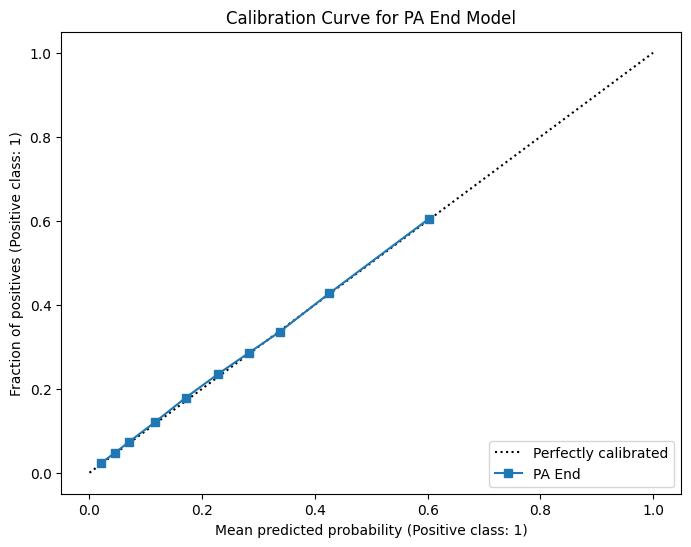

Probability metrics:
Log Loss: 0.44987
Brier Score: 0.14643
Distribution Check:
Real PA End Rate: 0.2308
Predicted Avg Prob: 0.2276
Simulated PA End Rate: 0.2273


In [19]:
X1_train = train_data[features]
y1_train = train_data['target1']

X1_val = val_data[features]
y1_val = val_data['target1']

X1_test = test_data[features]
y1_test = test_data['target1']

weights = compute_sample_weight(class_weight='balanced', y=y1_train)


xgb_out = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_out.fit(X1_train, y1_train, eval_set=[(X1_val, y1_val)], verbose=100, sample_weight=weights)

calibrated_out = CalibratedClassifierCV(FrozenEstimator(xgb_out), method='isotonic')
calibrated_out.fit(X1_val, y1_val)

y1_proba = calibrated_out.predict_proba(X1_test)[:, 1]

joblib.dump({
    'model': calibrated_out,
    'features': features
}, 'models/pa_end_model_v2.pkl')

importance = pd.Series(
    xgb_out.feature_importances_,
    index=X1_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y1_test == 1).astype(int),
    y1_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='PA End'
)
plt.title('Calibration Curve for PA End Model')
plt.show()

ll = log_loss(y1_test, y1_proba)
brier_score = brier_score_loss(y1_test, y1_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_pa_ends = (np.random.rand(len(y1_proba)) < y1_proba).astype(int)

real_rate = y1_test.mean()
pred_rate = y1_proba.mean()
sim_rate = simulated_pa_ends.mean()

print("Distribution Check:")
print(f"Real PA End Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated PA End Rate: {sim_rate:.4f}")

In [7]:
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss

results_df = X1_test.copy()
results_df['actual'] = y1_test.values
results_df['predicted_proba'] = y1_proba

results_df['is_two_strikes'] = results_df['strikes'] == 2

def get_metrics(df):
    if len(df) == 0: return None
    return pd.Series({
        'Log Loss': log_loss(df['actual'], df['predicted_proba']),
        'Brier Score': brier_score_loss(df['actual'], df['predicted_proba']),
        'Count': len(df),
        'Actual Rate': df['actual'].mean(),
        'Avg Pred Prob': df['predicted_proba'].mean()
    })

comparison = results_df.groupby('is_two_strikes').apply(get_metrics)
print("Comparison: Early Count vs. Two-Strike Count")
print(comparison)

results_df['count_string'] = results_df['balls'].astype(str) + "-" + results_df['strikes'].astype(str)
count_report = results_df.groupby('count_string').apply(get_metrics).sort_values('Log Loss')

print("\nGranular Count Report:")
print(count_report)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\578129942.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparison = results_df.groupby('is_two_strikes').apply(get_metrics)


Comparison: Early Count vs. Two-Strike Count
                Log Loss  Brier Score     Count  Actual Rate  Avg Pred Prob
is_two_strikes                                                             
False           0.376602     0.116303  714449.0     0.154073       0.152025
True            0.625956     0.217541  308042.0     0.408782       0.403343

Granular Count Report:
              Log Loss  Brier Score     Count  Actual Rate  Avg Pred Prob
count_string                                                             
3-0           0.157922     0.035928   10165.0     0.037678       0.070637
0-0           0.319114     0.093733  262634.0     0.113900       0.112363
1-0           0.386622     0.120033   98603.0     0.156405       0.153647
2-0           0.389288     0.121258   33043.0     0.158581       0.163170
0-1           0.399046     0.124881  133238.0     0.170837       0.167694
4-2           0.401993     0.112331       2.0     0.500000       0.426410
1-1           0.436784     0.139647

C:\Users\Lucas\AppData\Local\Temp\ipykernel_23048\578129942.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  count_report = results_df.groupby('count_string').apply(get_metrics).sort_values('Log Loss')


### Stage 2: Of PA Ends, predict Strikeout vs Non-Strikeout 

[0]	validation_0-logloss:0.52909
[100]	validation_0-logloss:0.33480
[200]	validation_0-logloss:0.33367
[300]	validation_0-logloss:0.33365
[311]	validation_0-logloss:0.33365
two_strikes                               0.583529
strikes                                   0.335143
location                                  0.009947
batter_loc_whiff_percentage               0.006624
batter_loc_strikeout_percentage           0.004271
prev_pitch_type_START                     0.003754
pitcher_loc_whiff_percentage              0.002643
pitch_type_FF                             0.002119
pitch_type_CH                             0.002019
batter_prev_whiff_percentage              0.001945
is_platoon                                0.001735
balls                                     0.001606
pitch_type_SI                             0.001447
pitcher_loc_strikeout_percentage          0.001429
full_count                                0.001283
pitcher_loc_swing_percentage              0.001086
sz_bot     

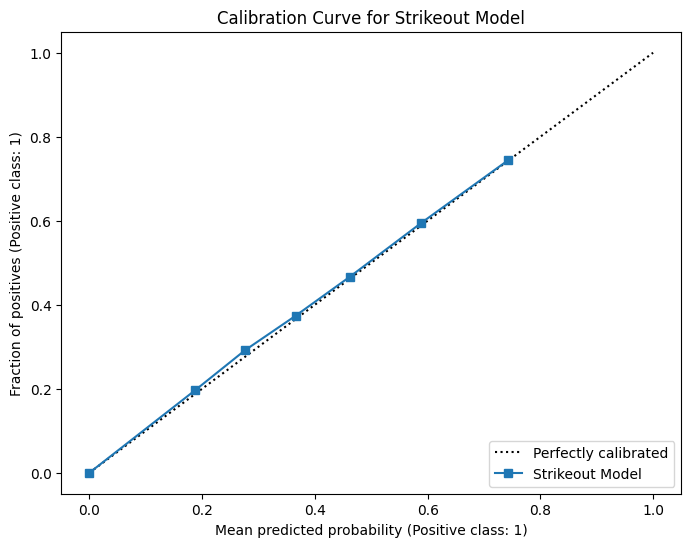

Probability metrics:
Log Loss: 0.33350
Brier Score: 0.11599
Distribution Check:
Real SO Rate: 0.2503
Predicted Avg Prob: 0.2465
Simulated SO Rate: 0.2463


In [15]:
train_data_s2 = train_data[train_data['target1'] == 1]
val_data_s2 = val_data[val_data['target1'] == 1]
test_data_s2 = test_data[test_data['target1'] == 1]

X2_train = train_data_s2[features]
y2_train = train_data_s2['target2']

X2_val = val_data_s2[features]
y2_val = val_data_s2['target2']

X2_test = test_data_s2[features]
y2_test = test_data_s2['target2']

xgb_so = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_so.fit(X2_train, y2_train, eval_set=[(X2_val, y2_val)], verbose=100)

calibrated_so = CalibratedClassifierCV(FrozenEstimator(xgb_so), method='isotonic')
calibrated_so.fit(X2_val, y2_val)

y2_proba = calibrated_so.predict_proba(X2_test)[:, 1]

joblib.dump({
    'model': calibrated_so,
    'features': features
}, 'models/so_model_v2.pkl')

importance = pd.Series(
    xgb_so.feature_importances_,
    index=X2_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y2_test == 1).astype(int),
    y2_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Strikeout Model'
)
plt.title('Calibration Curve for Strikeout Model')
plt.show()

ll = log_loss(y2_test, y2_proba)
brier_score = brier_score_loss(y2_test, y2_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_strikeouts = (np.random.rand(len(y2_proba)) < y2_proba).astype(int)

real_rate = y2_test.mean()
pred_rate = y2_proba.mean()
sim_rate = simulated_strikeouts.mean()

print("Distribution Check:")
print(f"Real SO Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated SO Rate: {sim_rate:.4f}")

### Stage 3: Of Balls in Play, predict Groundball vs Flyball

[0]	validation_0-logloss:0.68080
[100]	validation_0-logloss:0.64746
[200]	validation_0-logloss:0.64463
[300]	validation_0-logloss:0.64369
[400]	validation_0-logloss:0.64324
[500]	validation_0-logloss:0.64303
[600]	validation_0-logloss:0.64288
[700]	validation_0-logloss:0.64276
[800]	validation_0-logloss:0.64268
[900]	validation_0-logloss:0.64262
[1000]	validation_0-logloss:0.64254
[1071]	validation_0-logloss:0.64253
location                                  0.088648
pitch_type_FF                             0.082802
batter_loc_average_launch_angle           0.075516
pitcher_pitch_average_launch_angle        0.050732
pitch_type_SI                             0.048679
batter_pitch_average_launch_angle         0.032706
batter_loc_ground_ball_percentage         0.027936
is_platoon                                0.027363
batter_loc_fly_ball_percentage            0.018338
pitcher_loc_average_launch_angle          0.014015
pitch_type_ST                             0.013298
pitch_type_SL      

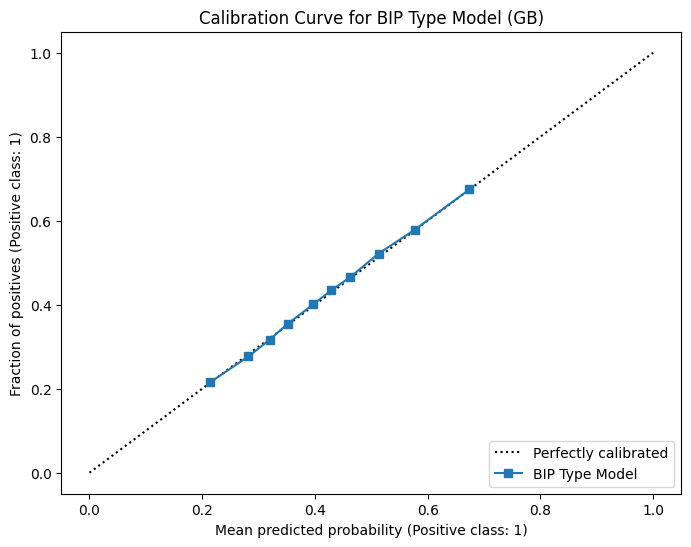

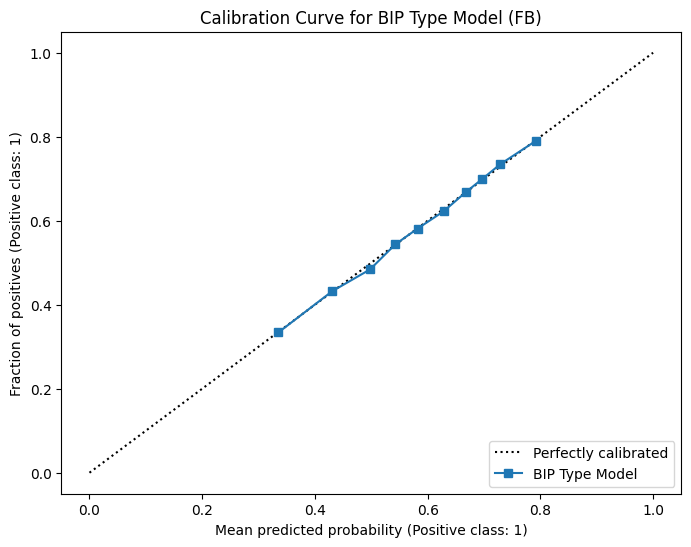

Probability metrics:
Log Loss: 0.64036
Brier Score: 0.22437
Distribution Check:
Real GB Rate: 0.4180
Predicted Avg Prob: 0.4163
Simulated GB Rate: 0.4178


In [9]:
train_data_s3 = train_data[(train_data['target1'] == 1) & (train_data['target2'] == 0)]
val_data_s3 = val_data[(val_data['target1'] == 1) & (val_data['target2'] == 0)]
test_data_s3 = test_data[(test_data['target1'] == 1) & (test_data['target2'] == 0)]

X3_train = train_data_s3[features]
y3_train = train_data_s3['target3']

X3_val = val_data_s3[features]
y3_val = val_data_s3['target3']

X3_test = test_data_s3[features]
y3_test = test_data_s3['target3']

xgb_bip = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=2000,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    min_child_weight=10,
    gamma=0.1,
    early_stopping_rounds=50
)

xgb_bip.fit(X3_train, y3_train, eval_set=[(X3_val, y3_val)], verbose=100)

calibrated_bip = CalibratedClassifierCV(FrozenEstimator(xgb_bip), method='isotonic')
calibrated_bip.fit(X3_val, y3_val)

y3_proba = calibrated_bip.predict_proba(X3_test)[:, 1]

joblib.dump({
    'model': calibrated_bip,
    'features': features
}, 'models/bip_model_v2.pkl')


importance = pd.Series(
    xgb_bip.feature_importances_,
    index=X3_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y3_test == 1).astype(int),
    y3_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='BIP Type Model'
)
plt.title('Calibration Curve for BIP Type Model (GB)')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y3_test == 0).astype(int),
    1 - y3_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='BIP Type Model'
)
plt.title('Calibration Curve for BIP Type Model (FB)')
plt.show()

ll = log_loss(y3_test, y3_proba)
brier_score = brier_score_loss(y3_test, y3_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_bip = (np.random.rand(len(y3_proba)) < y3_proba).astype(int)

real_rate = y3_test.mean()
pred_rate = y3_proba.mean()
sim_rate = simulated_bip.mean()

print("Distribution Check:")
print(f"Real GB Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated GB Rate: {sim_rate:.4f}")

### Stage 4: Of Flyballs, Predict Hard-Hit vs Not

[0]	validation_0-logloss:0.39142
[100]	validation_0-logloss:0.37042
[200]	validation_0-logloss:0.36868
[300]	validation_0-logloss:0.36805
[400]	validation_0-logloss:0.36776
[500]	validation_0-logloss:0.36764
[600]	validation_0-logloss:0.36744
[677]	validation_0-logloss:0.36743
batter_loc_hard_hit_bip_percentage        0.103663
location                                  0.057478
batter_prev_barrel_percentage             0.053887
batter_loc_average_exit_velocity          0.044367
batter_prev_barrels_per_pa                0.026729
two_strikes                               0.019760
strikes                                   0.019744
batter_prev_whiff_percentage              0.016130
full_count                                0.016068
balls                                     0.015381
pitch_type_FF                             0.015035
pitch_type_SI                             0.012827
batter_loc_swing_percentage               0.012344
pitch_type_CH                             0.011714
prev_pit

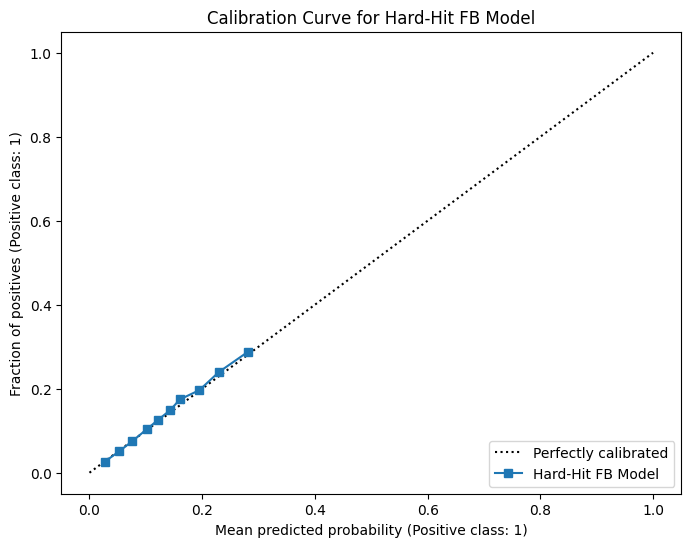

Probability metrics:
Log Loss: 0.37389
Brier Score: 0.11261
Distribution Check:
Real Hard-Hit FB Rate: 0.1374
Predicted Avg Prob: 0.1343
Simulated Hard-Hit FB Rate: 0.1357


In [10]:
train_data_s4 = train_data[(train_data['target1'] == 1) & (train_data['target2'] == 0) & (train_data['target3'] == 0)]
val_data_s4 = val_data[(val_data['target1'] == 1) & (val_data['target2'] == 0) & (val_data['target3'] == 0)]
test_data_s4 = test_data[(test_data['target1'] == 1) & (test_data['target2'] == 0) & (test_data['target3'] == 0)]

X4_train = train_data_s4[features]
y4_train = train_data_s4['target4']

X4_val = val_data_s4[features]
y4_val = val_data_s4['target4']

X4_test = test_data_s4[features]
y4_test = test_data_s4['target4']

xgb_fb = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=2000,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    min_child_weight=10,
    gamma=0.1,
    early_stopping_rounds=50
)

xgb_fb.fit(X4_train, y4_train, eval_set=[(X4_val, y4_val)], verbose=100)

calibrated_fb = CalibratedClassifierCV(FrozenEstimator(xgb_fb), method='isotonic')
calibrated_fb.fit(X4_val, y4_val)

y4_proba = calibrated_fb.predict_proba(X4_test)[:, 1]

joblib.dump({
    'model': calibrated_fb,
    'features': features
}, 'models/fb_model_v2.pkl')


importance = pd.Series(
    xgb_fb.feature_importances_,
    index=X4_train.columns
).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y4_test == 1).astype(int),
    y4_proba,
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='Hard-Hit FB Model'
)
plt.title('Calibration Curve for Hard-Hit FB Model')
plt.show()

ll = log_loss(y4_test, y4_proba)
brier_score = brier_score_loss(y4_test, y4_proba)

print('Probability metrics:')
print(f'Log Loss: {ll:.5f}')
print(f'Brier Score: {brier_score:.5f}')

simulated_bip = (np.random.rand(len(y4_proba)) < y4_proba).astype(int)

real_rate = y4_test.mean()
pred_rate = y4_proba.mean()
sim_rate = simulated_bip.mean()

print("Distribution Check:")
print(f"Real Hard-Hit FB Rate: {real_rate:.4f}")
print(f"Predicted Avg Prob: {pred_rate:.4f}")
print(f"Simulated Hard-Hit FB Rate: {sim_rate:.4f}")

### Combine previous models to generate probabilities for out types

In [20]:
def get_pitch_probabilities(X_full, xgb_pa, xgb_so, xgb_bb, X3_columns):
    p_pa_end = xgb_pa.predict_proba(X_full)[:, 1]
    p_no_end = 1.0 - p_pa_end

    p_so_given_end = xgb_so.predict_proba(X_full)[:, 1]

    X_for_stage3 = X_full.reindex(columns=X3_columns, fill_value=0.0)
    stage3_probs = xgb_bb.predict_proba(X_for_stage3)
    p_fb_given_non_so_end = stage3_probs[:, 0]
    p_gb_given_non_so_end = stage3_probs[:, 1]

    p_so = p_pa_end * p_so_given_end
    p_non_so_end = p_pa_end * (1.0 - p_so_given_end)

    p_go = p_non_so_end * p_gb_given_non_so_end
    p_fb = p_non_so_end * p_fb_given_non_so_end
    
    p_hhfb_given_fb = xgb_fb.predict_proba(X_full)[:, 1]

    p_hhfb = p_fb * p_hhfb_given_fb
    p_fo = p_fb * (1.0 - p_hhfb_given_fb)

    out = pd.DataFrame({
        'P(None)': p_no_end,
        'P(SO)': p_so,
        'P(GO)': p_go,
        'P(FO)': p_fo,
        'P(HHFB)': p_hhfb
    }, index=X_full.index)

    out['prob_sum'] = out[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']].sum(axis=1)
    return out

prob_df = get_pitch_probabilities(X1_test, calibrated_out, calibrated_so, calibrated_bip, X3_train.columns)
print(prob_df.head())
print(f"Probability sum min/max: {prob_df['prob_sum'].min():.6f} / {prob_df['prob_sum'].max():.6f}")

test_labels = model_data.loc[X1_test.index]
action_outcomes = ['strikeout', 'groundout', 'flyout', 'hit']

conditions = [
    (test_labels['outcome'] == 'strikeout'),
    
    (test_labels['bb_type'] == 'ground_ball') | 
    ((test_labels['outcome'] == 'groundout') & test_labels['bb_type'].isna()),
    
    (test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])) | 
    ((test_labels['outcome'].isin(['flyout', 'hit'])) & test_labels['bb_type'].isna()),

    
    (~test_labels['outcome'].isin(action_outcomes))
]

choices = [1, 2, 3, 0]

y_true = np.select(conditions, choices, default=0)

print(pd.Series(y_true).value_counts().sort_index())

final_prob_cols = ['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']
multi_log_loss = log_loss(y_true, prob_df[final_prob_cols], labels=[0, 1, 2, 3, 4])
print(f"Overall Multi-Class Log Loss (None/SO/GO/FO): {multi_log_loss:.4f}")


          P(None)  P(SO)     P(GO)     P(FO)   P(HHFB)  prob_sum
5794238  0.948341    0.0  0.013159  0.036752  0.001748       1.0
5794242  0.982122    0.0  0.005781  0.010279  0.001818       1.0
5794246  0.541262    0.0  0.203036  0.212577  0.043125       1.0
5794247  0.722159    0.0  0.163683  0.097792  0.016366       1.0
5794250  0.989665    0.0  0.004646  0.005431  0.000258       1.0
Probability sum min/max: 1.000000 / 1.000000
0    784418
1     59079
2     75841
3    103153
Name: count, dtype: int64
Overall Multi-Class Log Loss (None/SO/GO/FO): 0.6563


In [12]:
train_prob_df = get_pitch_probabilities(
    X1_train,
    calibrated_out,
    calibrated_so,
    calibrated_bip,
    X3_train.columns
)

train_labels = model_data.loc[X1_train.index]

action_outcomes = ['strikeout', 'groundout', 'flyout', 'hit']

conditions = [
    (train_labels['outcome'] == 'strikeout'),
    
    (train_labels['bb_type'] == 'ground_ball') | 
    ((train_labels['outcome'] == 'groundout') & train_labels['bb_type'].isna()),
    
    (train_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])) | 
    ((train_labels['outcome'].isin(['flyout', 'hit'])) & train_labels['bb_type'].isna()),
    
    (~train_labels['outcome'].isin(action_outcomes))
]

choices = [1, 2, 3, 0]

y_train = np.select(conditions, choices, default=0).astype(int)

final_prob_cols = ['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']

train_log_loss = log_loss(
    y_train,
    train_prob_df[final_prob_cols],
    labels=[0, 1, 2, 3, 4]
)

print(f"Train Multi-Class Log Loss: {train_log_loss:.4f}")

Train Multi-Class Log Loss: 0.6123


In [13]:
val_logloss = multi_log_loss
print(f"Train: {train_log_loss:.4f}, Val: {val_logloss:.4f}")
print(f"Gap: {val_logloss - train_log_loss:.4f}")

Train: 0.6123, Val: 0.6635
Gap: 0.0513


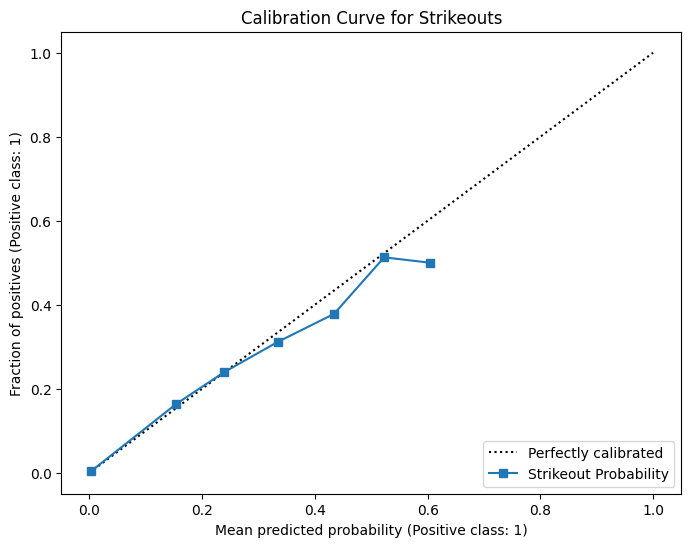

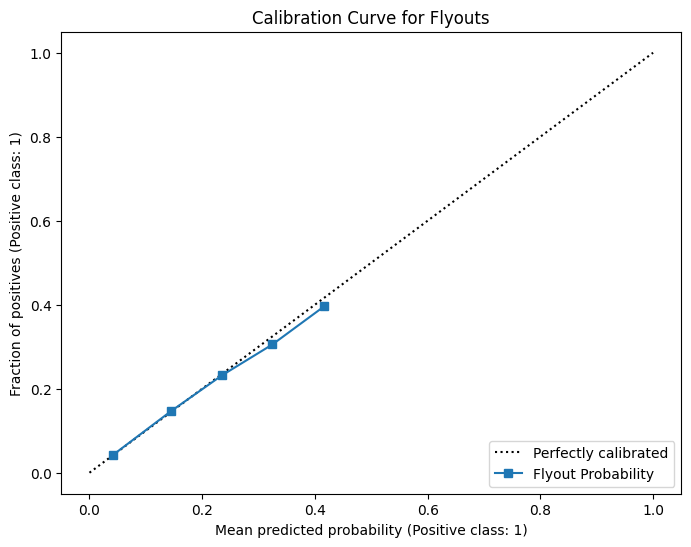

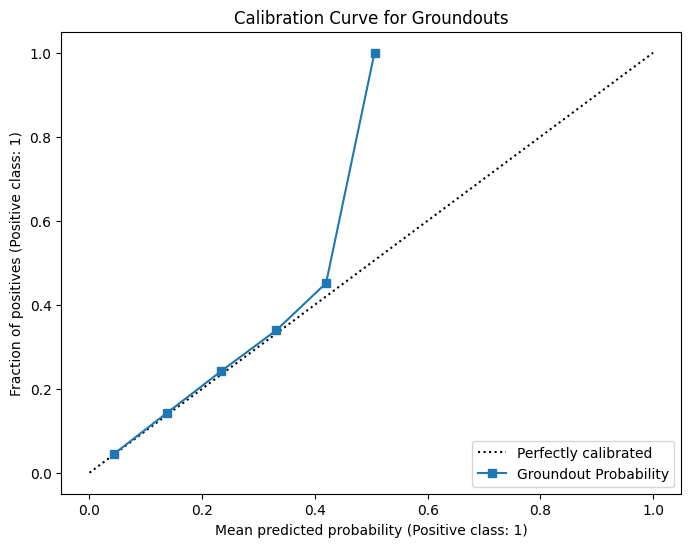

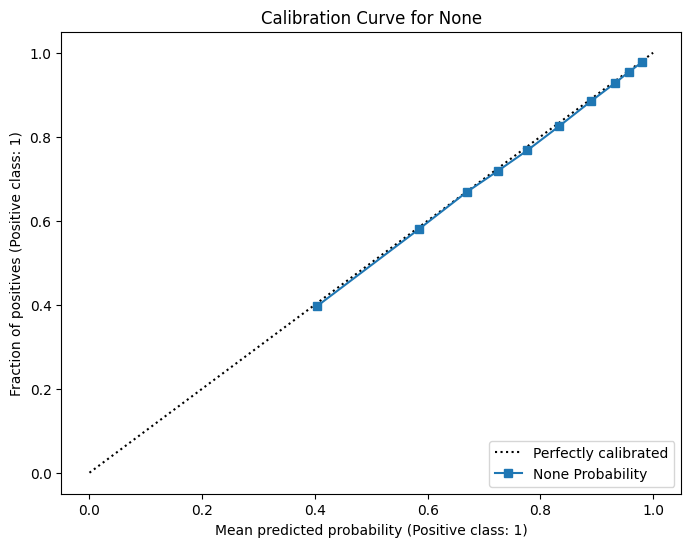

Highest P(SO): 60.59%
          P(None)     P(SO)     P(GO)     P(FO)     actual fly_detail
6648756  0.394057  0.605943  0.000000  0.000000       ball           
6574949  0.341712  0.602500  0.028559  0.026103  strikeout           
5990254  0.356375  0.589081  0.022358  0.026923       ball           
6750000  0.290909  0.563543  0.085746  0.056717  strikeout           
6801927  0.384296  0.563525  0.028790  0.021985    flyball        out
6355541  0.356375  0.562255  0.020727  0.052624  strikeout           
6513292  0.356375  0.562255  0.042841  0.036672  strikeout           
5960408  0.358258  0.560609  0.051113  0.027363  strikeout           
6770790  0.358258  0.560609  0.052980  0.026234  strikeout           
6690488  0.358258  0.560609  0.049111  0.030743  strikeout           
5966030  0.358258  0.560609  0.052672  0.027162       ball           
5825632  0.390164  0.558155  0.030641  0.019678  strikeout           
6052758  0.347823  0.555079  0.063038  0.033737  strikeout          

In [23]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

is_fly = test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])
is_hhfb = is_fly & model_data.loc[X1_test.index, 'is_hard_hit']
is_regular_fb = is_fly & ~model_data.loc[X1_test.index, 'is_hard_hit']

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 1).astype(int),
    prob_df['P(SO)'],
    n_bins=10,
    ax=ax,
    # strategy='quantile',
    name='Strikeout Probability'
)
plt.title('Calibration Curve for Strikeouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    is_regular_fb.astype(int),
    prob_df['P(FO)'],
    n_bins=10,
    ax=ax,
    # strategy='quantile',
    name='Flyout Probability'
)
plt.title('Calibration Curve for Flyouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 2).astype(int),
    prob_df['P(GO)'],
    n_bins=10,
    ax=ax,
    name='Groundout Probability'
)
plt.title('Calibration Curve for Groundouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 0).astype(int),
    prob_df['P(None)'],
    n_bins=10,
    ax=ax,
    strategy='quantile',
    name='None Probability'
)
plt.title('Calibration Curve for None')
plt.show()

results = X1_test.copy()
results[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']] = prob_df[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'P(HHFB)']]
test_labels = model_data.loc[X1_test.index]
conditions = [
    (test_labels['outcome'] == 'strikeout'),

    (test_labels['bb_type'] == 'ground_ball') | 
    ((test_labels['outcome'] == 'groundout') & test_labels['bb_type'].isna()),

    # hard-hit fly balls
    (
        test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup']) &
        model_data.loc[X1_test.index, 'is_hard_hit']
    ),

    # regular fly balls (non-hard-hit)
    (
        test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])
    ) & ~model_data.loc[X1_test.index, 'is_hard_hit'] |
    (
        (test_labels['outcome'].isin(['flyout', 'hit'])) &
        test_labels['bb_type'].isna()
    )
]

choices = ['strikeout', 'groundball', 'hard_hit_flyball', 'flyball']
results['actual'] = np.select(conditions, choices, default=test_labels['outcome'])

is_fly = (
    test_labels['bb_type'].isin(['fly_ball', 'line_drive', 'popup'])
    | test_labels['outcome'].isin(['flyout'])
)
results['fly_detail'] = np.where(
    is_fly,
    np.where(test_labels['outcome'] == 'hit', 'hit', 'out'),
    ''
)

top_so = results.sort_values('P(SO)', ascending=False).head(50)
print(f"Highest P(SO): {top_so['P(SO)'].iloc[0]:.2%}")
print(top_so[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

top_fo = results.sort_values('P(FO)', ascending=False).head(50)
print(f"Highest P(FO): {top_fo['P(FO)'].iloc[0]:.2%}")
print(top_fo[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

top_hhfb = results.sort_values('P(HHFB)', ascending=False).head(50)
print(f"Highest P(HHFB): {top_hhfb['P(HHFB)'].iloc[0]:.2%}")
print(top_hhfb[['P(HHFB)', 'actual', 'fly_detail']])

top_go = results.sort_values('P(GO)', ascending=False).head(50)
print(f"Highest P(GO): {top_go['P(GO)'].iloc[0]:.2%}")
print(top_go[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

top_none = results.sort_values('P(None)', ascending=False).head(50)
print(f"Highest P(None): {top_none['P(None)'].iloc[0]:.2%}")
print(top_none[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])

lowest_none = results.sort_values('P(None)', ascending=True).head(50)
print(f"Lowest P(None): {lowest_none['P(None)'].iloc[0]:.2%}")
print(lowest_none[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual', 'fly_detail']])